Logistic Regression

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
#Creating a pipeline to convert all pixels to tensor and then centering all data by using 0.1307 mean and 0.381 std. deviation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [4]:
EPOCHS    = 15
BATCH     = 64
LR        = 0.001
CLASS_A   = 0
CLASS_B   = 1
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_full = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_full  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.29MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.39MB/s]


In [6]:
#Taking only 0 & 1 data points
def filter_pair(dataset, class_a=0, class_b=1):
    idx = (dataset.targets == class_a) | (dataset.targets == class_b)
    dataset.data    = dataset.data[idx]
    dataset.targets = (dataset.targets[idx] == class_b).long()
    return dataset

In [7]:
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)  # single output neuron

    def forward(self, x):
        x = x.view(x.size(0), -1)   # flatten: [batch, 28*28]
        return self.linear(x)

INPUT_DIM = 28 * 28   # 784
model = LogisticRegression(INPUT_DIM)
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

LogisticRegression(
  (linear): Linear(in_features=784, out_features=1, bias=True)
)
Parameters: 785


In [8]:
# BCEWithLogitsLoss = Sigmoid + BCELoss (more numerically stable)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
model  = model.to(device)

print(f"Using device: {device}")

Using device: cpu


In [9]:
def train(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct = 0, 0

    for X, y in loader:
        X = X.to(device)
        y = y.float().to(device).unsqueeze(1)

        logits = model(X)
        loss   = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X.size(0)
        preds       = (torch.sigmoid(logits) >= 0.5).float()
        correct    += (preds == y).sum().item()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct   / len(loader.dataset) * 100
    return avg_loss, accuracy


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.float().to(device).unsqueeze(1)

            logits = model(X)
            loss   = criterion(logits, y)

            total_loss += loss.item() * X.size(0)
            preds       = (torch.sigmoid(logits) >= 0.5).float()
            correct    += (preds == y).sum().item()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct   / len(loader.dataset) * 100
    return avg_loss, accuracy

In [10]:
train_data = filter_pair(train_full,0,1)
test_data  = filter_pair(test_full,0,1)

print(f"Train samples: {len(train_data)}")
print(f"Test  samples: {len(test_data)}")

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

Train samples: 12665
Test  samples: 2115


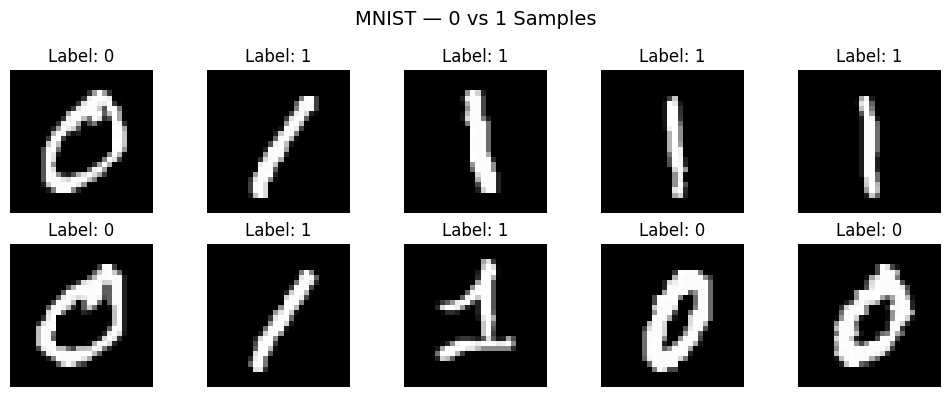

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flatten()):
    img, label = train_data[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Label: {int(label)}")
    ax.axis("off")

plt.suptitle("MNIST — 0 vs 1 Samples", fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
history = {"train_loss": [], "train_acc": [],
           "val_loss":   [], "val_acc":   []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = evaluate(model, test_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%")

Epoch  1/15 | Train Loss: 0.0543  Acc: 98.67% | Val Loss: 0.0106  Acc: 99.81%
Epoch  2/15 | Train Loss: 0.0099  Acc: 99.79% | Val Loss: 0.0057  Acc: 99.91%
Epoch  3/15 | Train Loss: 0.0063  Acc: 99.84% | Val Loss: 0.0040  Acc: 99.91%
Epoch  4/15 | Train Loss: 0.0049  Acc: 99.87% | Val Loss: 0.0032  Acc: 99.91%
Epoch  5/15 | Train Loss: 0.0039  Acc: 99.88% | Val Loss: 0.0030  Acc: 99.91%
Epoch  6/15 | Train Loss: 0.0033  Acc: 99.92% | Val Loss: 0.0024  Acc: 99.95%
Epoch  7/15 | Train Loss: 0.0029  Acc: 99.91% | Val Loss: 0.0025  Acc: 99.91%
Epoch  8/15 | Train Loss: 0.0026  Acc: 99.91% | Val Loss: 0.0021  Acc: 99.95%
Epoch  9/15 | Train Loss: 0.0023  Acc: 99.93% | Val Loss: 0.0020  Acc: 99.95%
Epoch 10/15 | Train Loss: 0.0021  Acc: 99.94% | Val Loss: 0.0020  Acc: 99.95%
Epoch 11/15 | Train Loss: 0.0019  Acc: 99.95% | Val Loss: 0.0019  Acc: 99.95%
Epoch 12/15 | Train Loss: 0.0018  Acc: 99.95% | Val Loss: 0.0018  Acc: 99.95%
Epoch 13/15 | Train Loss: 0.0016  Acc: 99.97% | Val Loss: 0.0023

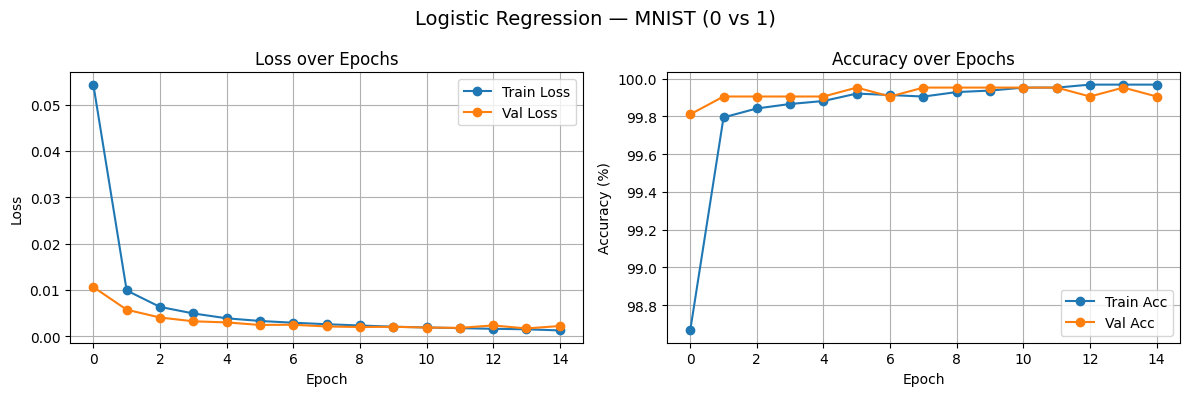

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(history["train_loss"], label="Train Loss", marker="o")
ax1.plot(history["val_loss"],   label="Val Loss",   marker="o")
ax1.set_title("Loss over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(history["train_acc"], label="Train Acc", marker="o")
ax2.plot(history["val_acc"],   label="Val Acc",   marker="o")
ax2.set_title("Accuracy over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True)

plt.suptitle("Logistic Regression — MNIST (0 vs 1)", fontsize=14)
plt.tight_layout()
plt.show()

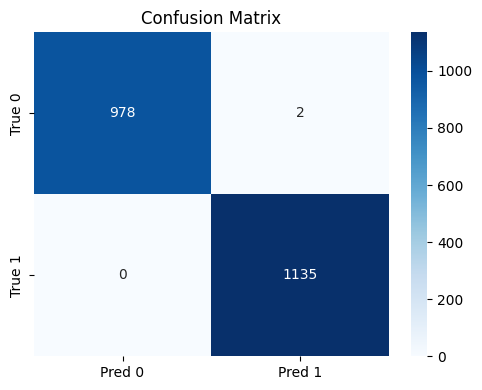

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135

    accuracy                           1.00      2115
   macro avg       1.00      1.00      1.00      2115
weighted avg       1.00      1.00      1.00      2115



In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        logits = model(X)
        preds  = (torch.sigmoid(logits) >= 0.5).float().cpu().squeeze()
        all_preds.extend(preds.tolist())
        all_labels.extend(y.tolist())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0","Pred 1"],
            yticklabels=["True 0","True 1"])
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Report
print(classification_report(all_labels, all_preds, target_names=["0", "1"]))

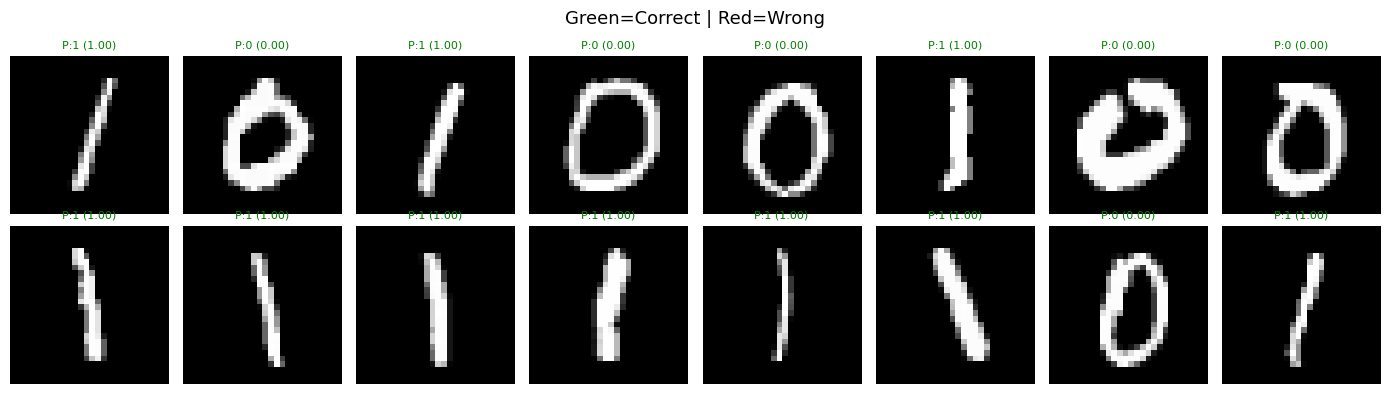

In [15]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))

model.eval()
samples = [test_data[i] for i in range(16)]

for i, (img, true_label) in enumerate(samples):
    ax = axes[i // 8][i % 8]

    with torch.no_grad():
        logit = model(img.unsqueeze(0).to(device))
        prob  = torch.sigmoid(logit).item()
        pred  = int(prob >= 0.5)

    ax.imshow(img.squeeze(), cmap="gray")
    color = "green" if pred == int(true_label) else "red"
    ax.set_title(f"P:{pred} ({prob:.2f})", color=color, fontsize=8)
    ax.axis("off")

plt.suptitle("Green=Correct | Red=Wrong", fontsize=13)
plt.tight_layout()
plt.show()

3 or 4 classification

In [18]:
train_data = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_data = filter_pair(train_data,3,4)
test_data  = filter_pair(test_data,3,4)

print(f"Train samples: {len(train_data)}")
print(f"Test  samples: {len(test_data)}")

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

Train samples: 11973
Test  samples: 1992


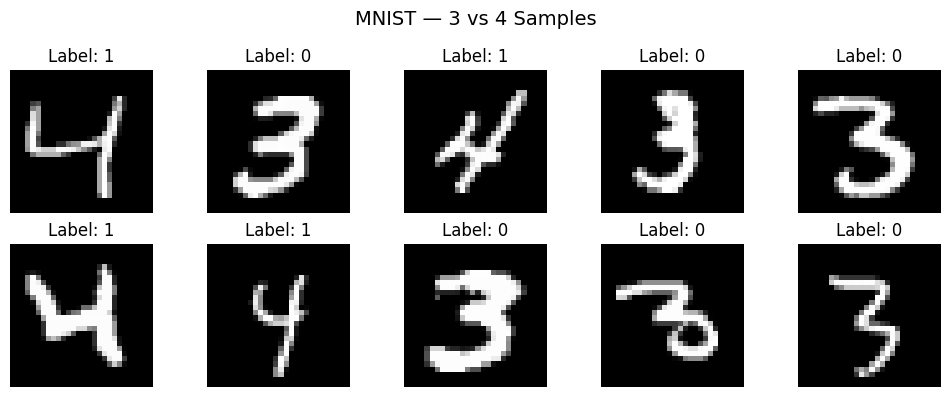

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flatten()):
    img, label = train_data[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Label: {int(label)}")
    ax.axis("off")

plt.suptitle("MNIST — 3 vs 4 Samples", fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
history = {"train_loss": [], "train_acc": [],
           "val_loss":   [], "val_acc":   []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = evaluate(model, test_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%")

Epoch  1/15 | Train Loss: 0.1488  Acc: 95.76% | Val Loss: 0.0280  Acc: 99.20%
Epoch  2/15 | Train Loss: 0.0269  Acc: 99.23% | Val Loss: 0.0213  Acc: 99.55%
Epoch  3/15 | Train Loss: 0.0210  Acc: 99.43% | Val Loss: 0.0191  Acc: 99.65%
Epoch  4/15 | Train Loss: 0.0184  Acc: 99.53% | Val Loss: 0.0184  Acc: 99.65%
Epoch  5/15 | Train Loss: 0.0171  Acc: 99.54% | Val Loss: 0.0178  Acc: 99.60%
Epoch  6/15 | Train Loss: 0.0163  Acc: 99.57% | Val Loss: 0.0176  Acc: 99.65%
Epoch  7/15 | Train Loss: 0.0150  Acc: 99.67% | Val Loss: 0.0190  Acc: 99.60%
Epoch  8/15 | Train Loss: 0.0145  Acc: 99.62% | Val Loss: 0.0180  Acc: 99.65%
Epoch  9/15 | Train Loss: 0.0139  Acc: 99.68% | Val Loss: 0.0171  Acc: 99.65%
Epoch 10/15 | Train Loss: 0.0135  Acc: 99.67% | Val Loss: 0.0172  Acc: 99.65%
Epoch 11/15 | Train Loss: 0.0130  Acc: 99.65% | Val Loss: 0.0168  Acc: 99.70%
Epoch 12/15 | Train Loss: 0.0125  Acc: 99.69% | Val Loss: 0.0178  Acc: 99.65%
Epoch 13/15 | Train Loss: 0.0121  Acc: 99.70% | Val Loss: 0.0171

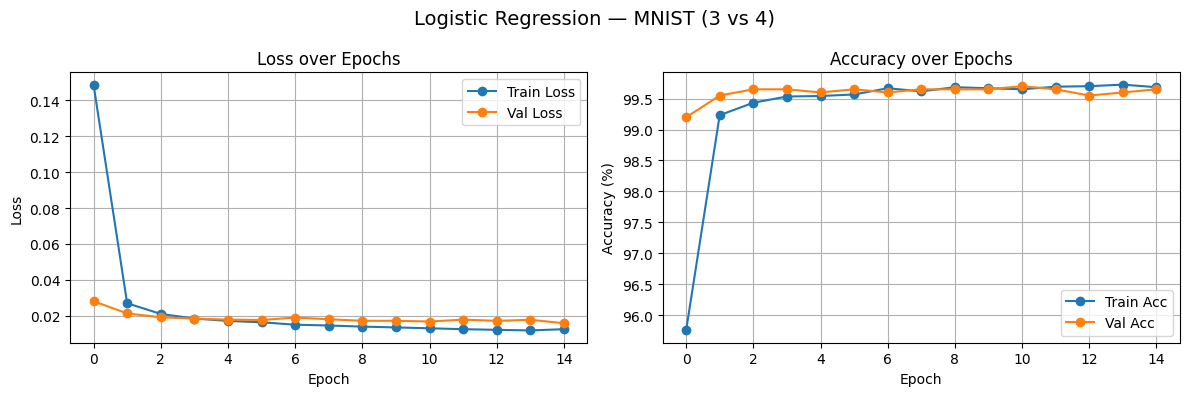

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(history["train_loss"], label="Train Loss", marker="o")
ax1.plot(history["val_loss"],   label="Val Loss",   marker="o")
ax1.set_title("Loss over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(history["train_acc"], label="Train Acc", marker="o")
ax2.plot(history["val_acc"],   label="Val Acc",   marker="o")
ax2.set_title("Accuracy over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True)

plt.suptitle("Logistic Regression — MNIST (3 vs 4)", fontsize=14)
plt.tight_layout()
plt.show()

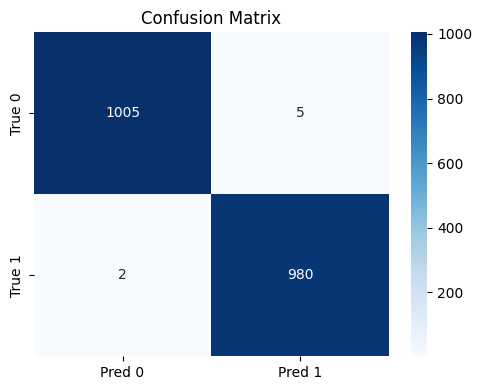

              precision    recall  f1-score   support

           3       1.00      1.00      1.00      1010
           4       0.99      1.00      1.00       982

    accuracy                           1.00      1992
   macro avg       1.00      1.00      1.00      1992
weighted avg       1.00      1.00      1.00      1992



In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        logits = model(X)
        preds  = (torch.sigmoid(logits) >= 0.5).float().cpu().squeeze()
        all_preds.extend(preds.tolist())
        all_labels.extend(y.tolist())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0","Pred 1"],
            yticklabels=["True 0","True 1"])
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Report
print(classification_report(all_labels, all_preds, target_names=["3", "4"]))

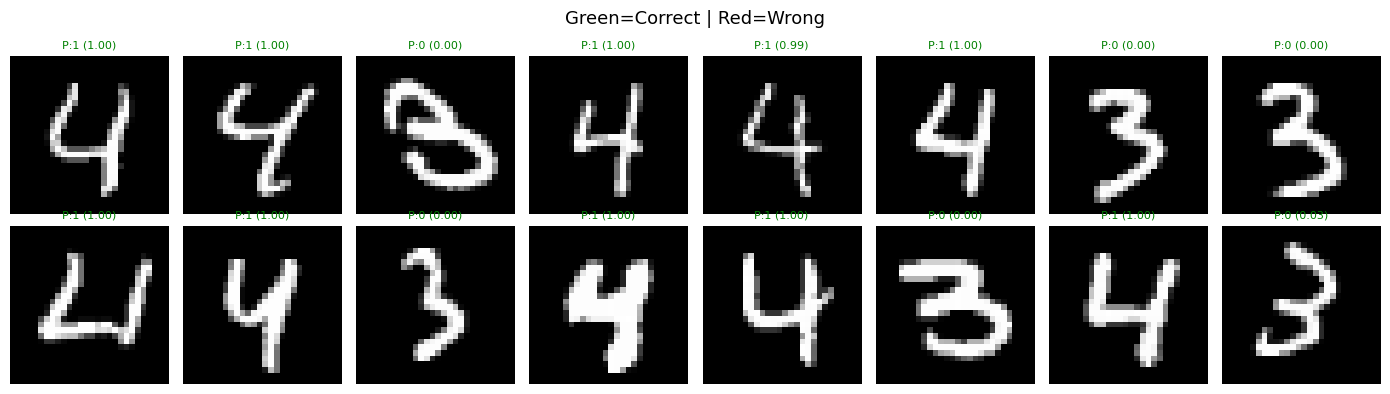

In [23]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))

model.eval()
samples = [test_data[i] for i in range(16)]

for i, (img, true_label) in enumerate(samples):
    ax = axes[i // 8][i % 8]

    with torch.no_grad():
        logit = model(img.unsqueeze(0).to(device))
        prob  = torch.sigmoid(logit).item()
        pred  = int(prob >= 0.5)

    ax.imshow(img.squeeze(), cmap="gray")
    color = "green" if pred == int(true_label) else "red"
    ax.set_title(f"P:{pred} ({prob:.2f})", color=color, fontsize=8)
    ax.axis("off")

plt.suptitle("Green=Correct | Red=Wrong", fontsize=13)
plt.tight_layout()
plt.show()